# Exploratory Data Analysis: Citation Impact Prediction

This notebook explores the dataset used to predict whether a paper is high-impact.

Goals:
- Understand dataset structure and class balance
- Analyze feature distributions
- Identify predictive features
- Detect and remove leakage-prone variables
- Select features for modeling

### Imports + Setup

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

### Load data

In [29]:
df = pd.read_csv("../data/processed/papers.csv")

print("Shape:", df.shape)
df.head()

Shape: (5277, 19)


,paper_id,publication_year,cited_by_count,num_authors,num_institutions,num_countries,is_multi_institution,is_international,has_elite_affiliation,has_industry,has_gov_nonprofit,has_us_institution,is_open_access,is_journal,paper_age,high_impact,log_num_authors,log_num_institutions,log_num_countries
0,https://openalex.org/W2784446974,2018,0,1,1,1,0,0,0,0,0,0,1,0,8,0,0.693147,0.693147,0.693147
1,https://openalex.org/W2971141423,2018,0,1,1,1,0,0,0,0,0,0,0,0,8,0,0.693147,0.693147,0.693147
2,https://openalex.org/W2897768195,2018,10,5,2,1,1,0,0,0,0,0,0,0,8,0,1.791759,1.098612,0.693147
3,https://openalex.org/W2908411605,2018,22,4,3,2,1,1,0,0,0,0,0,1,8,0,1.609438,1.386294,1.098612
4,https://openalex.org/W2790283083,2018,0,5,1,1,0,0,0,0,0,1,1,1,8,0,1.791759,0.693147,0.693147


### Data overview

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5277 entries, 0 to 5276
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   paper_id               5277 non-null   object 
 1   publication_year       5277 non-null   int64  
 2   cited_by_count         5277 non-null   int64  
 3   num_authors            5277 non-null   int64  
 4   num_institutions       5277 non-null   int64  
 5   num_countries          5277 non-null   int64  
 6   is_multi_institution   5277 non-null   int64  
 7   is_international       5277 non-null   int64  
 8   has_elite_affiliation  5277 non-null   int64  
 9   has_industry           5277 non-null   int64  
 10  has_gov_nonprofit      5277 non-null   int64  
 11  has_us_institution     5277 non-null   int64  
 12  is_open_access         5277 non-null   int64  
 13  is_journal             5277 non-null   int64  
 14  paper_age              5277 non-null   int64  
 15  high

In [41]:
df.describe()

,publication_year,cited_by_count,num_authors,num_institutions,num_countries,is_multi_institution,is_international,has_elite_affiliation,has_industry,has_gov_nonprofit,has_us_institution,is_open_access,is_journal,paper_age,high_impact,log_num_authors,log_num_institutions,log_num_countries
count,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000
mean,2018.998484,10.837976,3.141368,1.501800,1.163350,0.266060,0.120902,0.046049,0.038658,0.035626,0.102899,0.420315,0.585181,7.001516,0.102141,1.262732,0.856889,0.753124
std,0.816340,51.839433,4.248992,1.154254,0.526981,0.441938,0.326044,0.209611,0.192798,0.185374,0.303856,0.493656,0.492737,0.816340,0.302863,0.493528,0.309614,0.173847
min,2018.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,0.693147,0.693147,0.693147
25%,2018.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,0.693147,0.693147,0.693147
50%,2019.000000,1.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,7.000000,0.000000,1.098612,0.693147,0.693147
75%,2020.000000,7.000000,4.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,8.000000,0.000000,1.609438,1.098612,0.693147
max,2020.000000,2461.000000,100.000000,25.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,4.615121,3.258097,2.564949


### Target analysis

In [42]:
class_counts = df["high_impact"].value_counts()
class_props = df["high_impact"].value_counts(normalize=True)

print(class_counts)
print(class_props)

high_impact
0    4738
1     539
Name: count, dtype: int64
high_impact
0    0.897859
1    0.102141
Name: proportion, dtype: float64


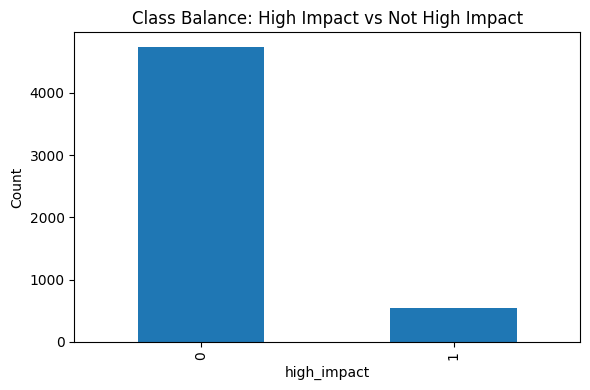

In [43]:
plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Class Balance: High Impact vs Not High Impact")
plt.xlabel("high_impact")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../results/class_balance.png")
plt.show()

### Citation distribution

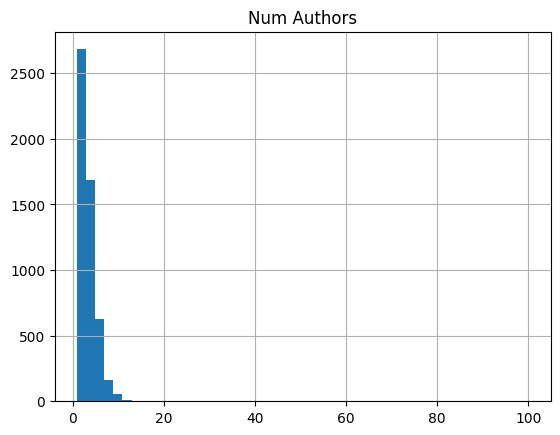

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["cited_by_count"], bins=50)
plt.title("Citation Count Distribution")
plt.xlabel("Cited By Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../results/citation_distribution.png")
plt.show()

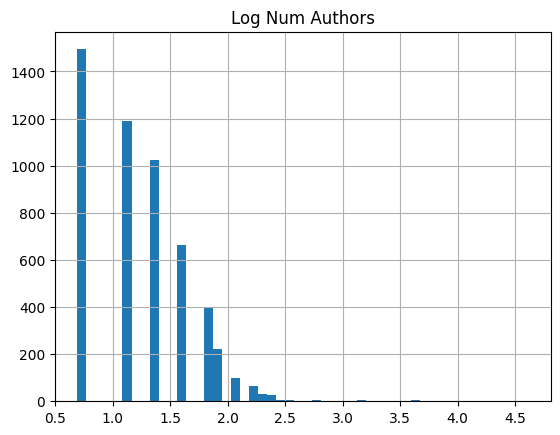

In [36]:
df["log_num_authors"].hist(bins=50)
plt.title("Log Num Authors")
plt.show()

## Correlation analysis

In [37]:
df.corr(numeric_only=True)["high_impact"].sort_values(ascending=False)

high_impact              1.000000
cited_by_count           0.437974
log_num_institutions     0.276919
is_multi_institution     0.259983
num_institutions         0.242644
is_international         0.228093
log_num_countries        0.226933
num_countries            0.207768
log_num_authors          0.189374
has_elite_affiliation    0.149818
has_us_institution       0.130861
is_journal               0.120134
has_industry             0.088171
num_authors              0.074498
has_gov_nonprofit        0.053332
paper_age                0.003973
publication_year        -0.003973
is_open_access          -0.056477
Name: high_impact, dtype: float64

## Compare groups

In [38]:
df.groupby("high_impact")["num_authors"].mean()
df.groupby("high_impact")["num_institutions"].mean()

high_impact
0    1.407345
1    2.332096
Name: num_institutions, dtype: float64

## Binary feature analysis

In [39]:
df.groupby("high_impact")["is_international"].mean()
df.groupby("high_impact")["has_elite_affiliation"].mean()

high_impact
0    0.035458
1    0.139147
Name: has_elite_affiliation, dtype: float64